# Introduction

## loading packages

In [90]:
import movement
from pathlib import Path
from movement.io import load_dataset
from movement.filtering import filter_by_confidence, rolling_filter

# names : variables

In [16]:
file_name = "mouse044_task1_annotator1.slp.250811_154148.predictions.slp"
predictions_dir = Path.home() / "osss" / "CalMS21" / "better_model" / "predictions"
file_path = predictions_dir / file_name

In [17]:
# data loading
ds = load_dataset(file_path, fps=30)

# Understand movement packages 
## Movement anatomy

In [18]:
ds

<xarray.Dataset> Size: 598kB
Dimensions:     (time: 3394, space: 2, keypoint: 7, individual: 2)
Coordinates:
  * time        (time) float64 27kB 0.0 0.03333 0.06667 ... 113.0 113.1 113.1
  * space       (space) <U1 8B 'x' 'y'
  * keypoint    (keypoint) <U9 252B 'nose' 'right_ear' ... 'tail_base'
  * individual  (individual) <U10 80B 'intruder_w' 'resident_b'
Data variables:
    position    (time, space, keypoint, individual) float32 380kB 740.9 ... 1...
    confidence  (time, keypoint, individual) float32 190kB 0.8419 ... 0.7794
Attributes:
    source_software:  SLEAP
    ds_type:          poses
    fps:              30.0
    time_unit:        seconds
    source_file:      /Users/margotrefuge/osss/CalMS21/better_model/predictio...

### Dimension

### Coordinates
Labels along each axes : 
- x, y 
- keypoints : nose_x ,.... 
- times = sec 

### Data variables 

### Attributes
Metadata

# Application 

In [21]:
# index selection function : isel() --> numeric selection 
# selection function : sel() --> data by name []

# First individual, first time point
ds.isel(individual=0, time=0)

# 0-10 seconds, two specific keypoints
ds.sel(time=slice(0, 10), keypoint=["left_ear", "right_ear"], individual=["resident_b"])

<xarray.Dataset> Size: 10kB
Dimensions:     (time: 301, space: 2, keypoint: 2, individual: 1)
Coordinates:
  * time        (time) float64 2kB 0.0 0.03333 0.06667 0.1 ... 9.933 9.967 10.0
  * space       (space) <U1 8B 'x' 'y'
  * keypoint    (keypoint) <U9 72B 'left_ear' 'right_ear'
  * individual  (individual) <U10 40B 'resident_b'
Data variables:
    position    (time, space, keypoint, individual) float32 5kB 833.1 ... 442.9
    confidence  (time, keypoint, individual) float32 2kB 0.9011 ... 0.8497
Attributes:
    source_software:  SLEAP
    ds_type:          poses
    fps:              30.0
    time_unit:        seconds
    source_file:      /Users/margotrefuge/osss/CalMS21/better_model/predictio...

Question : average keypoint 
-> along the dataset : ds
-> look at the position : position
-> the mean position : mean
-> of all the dataset : dim = keypoint


==> same for other statistics ! 

In [22]:
ds.position.mean(dim="keypoint")

<xarray.DataArray 'position' (time: 3394, space: 2, individual: 2)> Size: 54kB
784.7 790.8 451.5 394.1 785.1 793.8 ... 442.9 162.7 876.6 257.0 442.6 164.5
Coordinates:
  * time        (time) float64 27kB 0.0 0.03333 0.06667 ... 113.0 113.1 113.1
  * space       (space) <U1 8B 'x' 'y'
  * individual  (individual) <U10 80B 'intruder_w' 'resident_b'

Question : minimum along the x coordinate

In [ ]:
minx = ds.position.sel(space="x").min(dim="time") # select x coordinate

question : tail base ---> time 

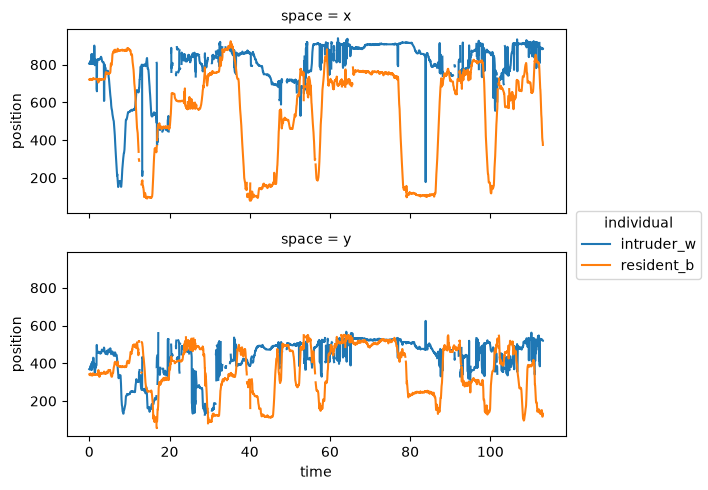

In [34]:
tail_base_pos = ds.sel(keypoint="tail_base").position
tail_base_pos.plot.line(
    x="time", hue="individual", row="space", aspect=2, size=2.5
)

Keep working with the loaded dataset ds and try the following:

- Select the position of the neck keypoint for the first 60 seconds of the recording.
- Compute the median position of the neck across the selected time window, for each individual. 
- Which individual is closer to the left side of the arena (i.e. where x is zero)?
- Show the centroid position of both individuals as a line plot across time. Plot the x and y positions on different subplots and assign a different colour to each individual.
Bonus

- Select 3 keypoints of resident_b, and show their confidence values across time as a line plot. Plot each keypoint on a different subplot.
- Visualise the overall distribution of confidence scores in the dataset, using plot.hist. Does anything surprise you about the distribution?


In [ ]:
ds.position.sel(time=slice(0,10), keypoints=["neck"])

In [ ]:
ds.position.median()

<xarray.DataArray 'position' (time: 3394, space: 2, individual: 2)> Size: 109kB
785.0 805.2 464.7 405.5 787.9 809.4 ... 425.9 170.2 884.0 220.5 425.8 172.5
Coordinates:
  * time        (time) float64 27kB 0.0 0.03333 0.06667 ... 113.0 113.1 113.1
  * space       (space) <U1 8B 'x' 'y'
  * individual  (individual) <U10 80B 'intruder_w' 'resident_b'

In [60]:
neck_pos = ds.position.sel(time=slice(0,10), keypoint=["neck"], space="x")

In [61]:
neck = neck_pos.median(dim="time") #=> intruder most left

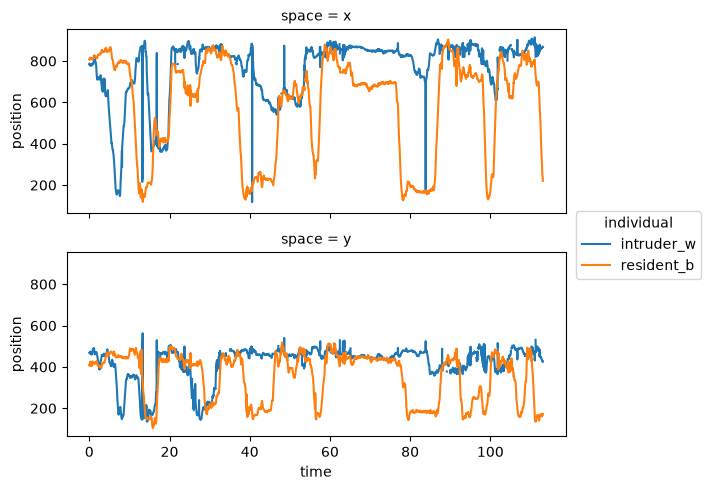

In [64]:
neck_pos = ds.sel(keypoint="neck").position
neck_pos.plot.line(
    x="time", hue="individual", row="space", aspect=2, size=2.5
)

In [77]:
resB = ds.sel(time=slice(0, 10), keypoint=["left_ear", "right_ear", "nose"], individual=["resident_b"]).confidence

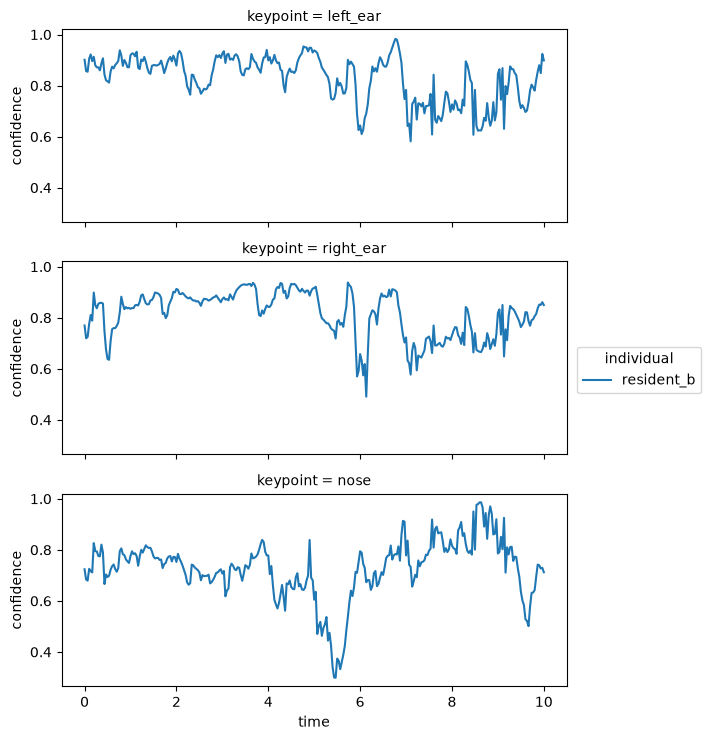

In [79]:
resB.plot.line(
    x="time", row="keypoint", aspect=2, size=2.5
)

Exercices : Visualise the overall distribution of confidence scores in the dataset, using plot.hist. Does anything surprise you about the distribution?

In [ ]:
tail_base_pos = ds.sel(keypoint="tail_base").position

tail_base_pos.plot.line(
    x="time", hue="individual", row="space", aspect=2, size=2.5
)

In [82]:
conf = ds.confidence

(array([ 1343.,   342.,  1539.,  2111.,  3388.,  7191., 14070., 14299.,
         2172.,    53.]),
 array([0.        , 0.11648004, 0.23296008, 0.3494401 , 0.46592015,
        0.5824002 , 0.6988802 , 0.81536025, 0.9318403 , 1.04832029,
        1.16480041]),
 <BarContainer object of 10 artists>)

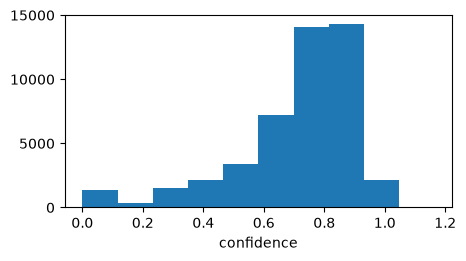

In [94]:
conf.plot.hist(aspect=2, size=2.5)

# Clean motion track 
### Filter

Filter function by confidence

In [91]:
position_filtered = filter_by_confidence(
    ds.position, ds.confidence, threshold=0.7, print_report=True
)

Missing points (marked as NaN) in input:

keypoint                 nose         right_ear          left_ear              neck        right_hip          left_hip          tail_base
individual                                                                                                                               
intruder_w  368/3394 (10.84%)  330/3394 (9.72%)  315/3394 (9.28%)  211/3394 (6.22%)  224/3394 (6.6%)  216/3394 (6.36%)  474/3394 (13.97%)
resident_b    31/3394 (0.91%)    8/3394 (0.24%)   20/3394 (0.59%)    6/3394 (0.18%)   17/3394 (0.5%)    8/3394 (0.24%)   123/3394 (3.62%)
Missing points (marked as NaN) in output:

keypoint                  nose           right_ear           left_ear                neck           right_hip            left_hip           tail_base
individual                                                                                                                                           
intruder_w   1507/3394 (44.4%)  1617/3394 (47.64%)  1612/3394 (

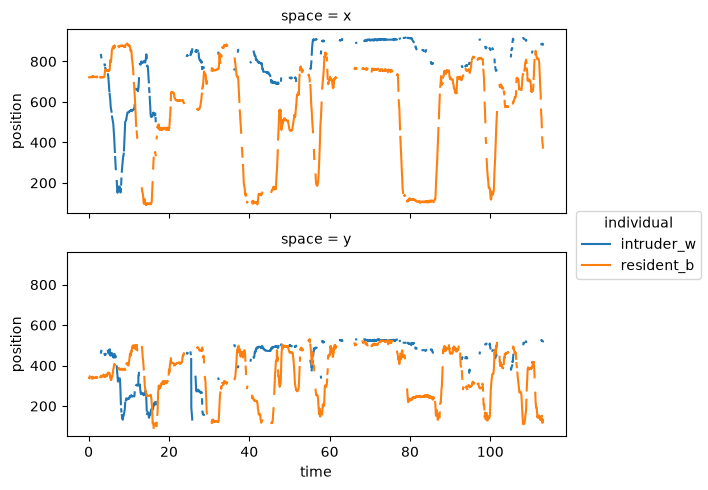

In [92]:
position_filtered.sel(keypoint="tail_base").plot.line(
    x="time", hue="individual", row="space", aspect=2, size=2.5
)

Function : rolling filter =  A rolling median filter can suppress this noise by replacing each value with the median of the surrounding frames within a sliding window.(notebook)

In [95]:
position_smooth = rolling_filter(
    position_filtered, window=5, statistic="median"
)

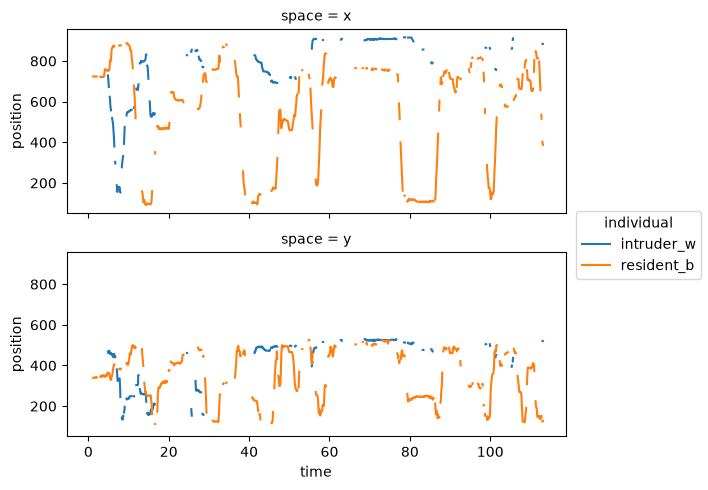

In [96]:
position_smooth.sel(keypoint="tail_base").plot.line(
    x="time", hue="individual", row="space", aspect=2, size=2.5
)

Results : loose more data 
==> bc the average of the windows is missing also 
==> mean period = 2 : if two values within the 7 windows : take value of those two

Exercices : Try applying rolling_filter to position_filtered with window values of 3 and 11 (keeping statistic="median"). For each, plot the tail_base keypoint trajectory. How do the results differ?

In [99]:
position_smooth = rolling_filter(
    position_filtered, window=3, statistic="median"
)

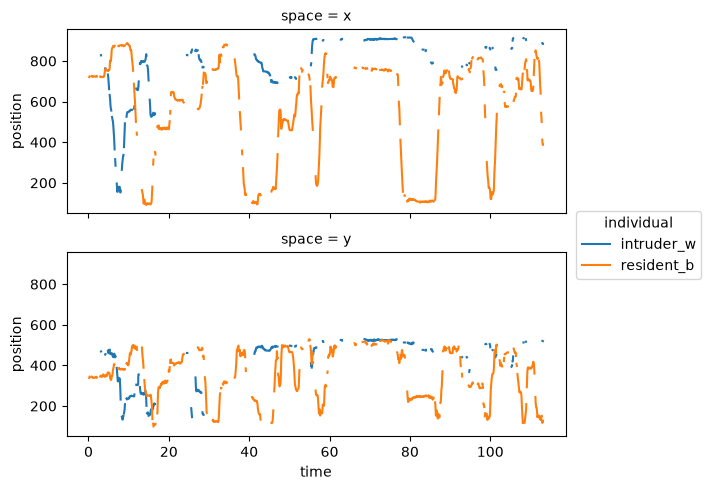

In [100]:
position_smooth.sel(keypoint="tail_base").plot.line(
    x="time", hue="individual", row="space", aspect=2, size=2.5
)

In [101]:
position_smooth = rolling_filter(
    position_filtered, window=11, statistic="median"
)

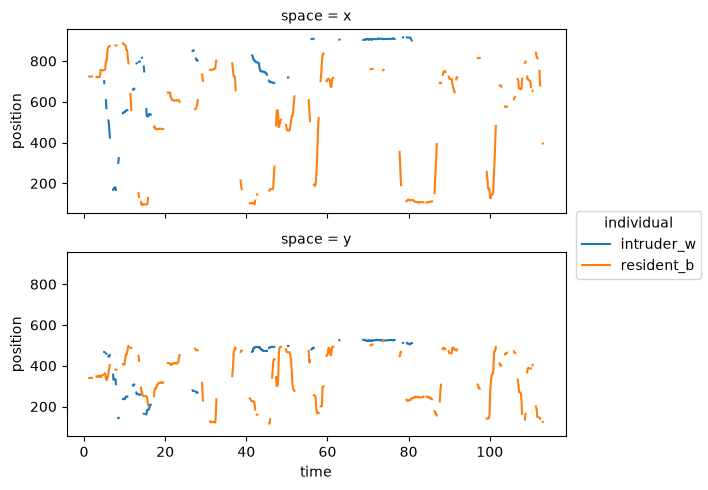

In [102]:
position_smooth.sel(keypoint="tail_base").plot.line(
    x="time", hue="individual", row="space", aspect=2, size=2.5
)

By default (min_periods=None), any window containing a NaN returns NaN, expanding existing gaps. Using window=11, try setting min_periods=1 and plot the result. How does the output differ? What is the trade-off? (Tip: set print_report=True to observe the effect on the number of missing values.)

In [103]:
window=11

In [104]:

position_smooth = rolling_filter(position_filtered, window, min_periods=2, statistic="median")


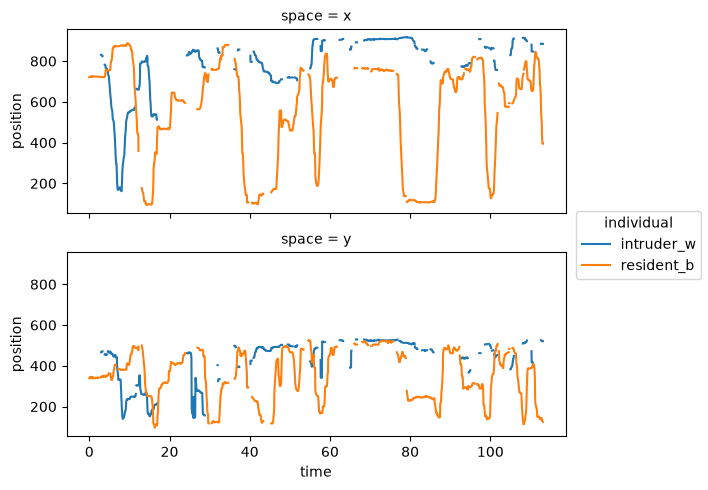

In [105]:
position_smooth.sel(keypoint="tail_base").plot.line(
    x="time", hue="individual", row="space", aspect=2, size=2.5
)

Much less data NA

# Interpolation

I have point - Na - point, smooth movement = draw a line